# Bias News 
### Data Acquisition, Exploration, and Preprocessing

This notebook includes code and explanations for data acqusition, exploration and preprocessing for the bias news detection model.  

## Imports

In [2]:
# basic imports
import pandas as pd
from pandas import DataFrame
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
import string
%matplotlib inline

# imports for Kaggle downloads
import kagglehub
from kagglehub import KaggleDatasetAdapter

# nltk imports
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import CountVectorizer

# data acquisition and visualization imports
from datasets import load_dataset
from wordcloud import WordCloud


##### A couple of installs you may need

In [3]:
#!pip install transformers
#!pip install datasets
#nltk.download("wordnet")

## Data Acquisition and Preprocessing

Initially we attempted to use the BIGNEWS Datasets which is labeled by "source".  This is a dataset containing three files, each of which has approximately 780,000 articles.  One dataset contains left leaning articles, one contains right leaning articles, and one contains center articles.  These were created by scraping websites that are known to be left leaning, right leaning, or center leaning.  The articles are not read or labeled by humans.  This achieved poor results but we retained the dataset for testing.  

The first working model was created with a set of three datasets from hugging face.  

*ds1* - "The Political Bias dataset contains 658 synthetic statements, each annotated with a bias rating ranging from 0 to 4. These ratings represent a spectrum from highly conservative (0) to highly liberal (4). The dataset was generated using GPT-4, aiming to facilitate research and development in bias detection and reduction in textual data. Special emphasis was placed on distinguishing between moderate biases on both sides, as this has proven to be more challenging for models compared to identifying extreme biases."  

Available at https://huggingface.co/datasets/cajcodes/political-bias.

*ds2* - Dataset of political tweets.  We odn't know much about the source of this dataset but it has been used in a few bias detection models on Hugging Face.  Available at... https://huggingface.co/datasets/Jacobvs/PoliticalTweets.

*ds3* - This dataset card contains very short paragraphs (2-3 sentences) which are labelled as either 'liberal' or 'conservative'. It has been generated using GPT-4. The code to generate the data can be found here: https://github.com/jyotisn79/Labelled_data_generator.  All the entries has also been manually checked to ensure that the paragraph accurately maps to the labels. Note that the lables may not be representative of political discourses outside of the United States.

Label Mapping: {'conservative': 0, 'liberal': 1}

Issue Type Mapping: {'economic': 0, 'environmental': 1, 'family/gender': 2, 'geo-political and foreign policy': 3, 'political': 4, 'racial justice and immigration': 5, 'religious': 6, 'social, health and education': 7}

Available at https://huggingface.co/datasets/JyotiNayak/political_ideologies.

### Working with the Hugging Face Datasets

In [4]:
# load datasets
ds1 = load_dataset("cajcodes/political-bias")
ds2 = load_dataset("Jacobvs/PoliticalTweets")
ds3 = load_dataset("JyotiNayak/political_ideologies")

# create dataframes
df1 = ds1["train"].to_pandas()
df2 = ds2["train"].to_pandas()
df3 = ds3["train"].to_pandas()

#### Dataset 1

This dataset has labels from 0 to 4 indicating the level of political bias.  Our other datasets are mapped with only 0 and 1 to indicate liberal or conservative.  In order to combine the datasets, here we convert all 0s and 1s to 0s, all 3s and 4s to 1s and we  discard all of the 2s.  This will leave us with a dataset mapped 0 for conservative and 1 for liberal (matching the other two datasets). 

The df1 dataset has only two columns, "text" and "label" so we will make the other two datasets match this format.  

In [5]:
# verifying labels
print(df1["label"].unique())

# drop rows where y == 2
df1 = df1[df1["label"] != 2].copy()

# map values
df1["label"] = df1["label"].map({0: 0, 1: 0, 3: 1, 4: 1})

# check to see if values mapped properly
print(df1["label"].unique())

# check for null values
df1.isna().sum()

[0 1 2 3 4]
[0 1]


text     0
label    0
dtype: int64

In [6]:
df1.head()

,text,label
0,The government should reduce taxes significant...,0
1,Cutting welfare programs is necessary to encou...,0
2,A strong military is essential for national se...,0
3,Deregulation is crucial to promote free market...,0
4,Traditional family values should be upheld to ...,0


#### Dataset 2

This dataset has several columns and the label column is named "labels".  We drop all columns except text and labels and change "labels" to "label".

In [7]:
# drop extra columns
df2.drop(columns= ["index", "date", "id", "username", "party"], inplace=True)

#rename column to make label columns match
df2.rename(columns={"labels": "label"}, inplace= True)

# check formatting
df2.head()

# check for null values
df2.isna().sum()

text     0
label    0
dtype: int64

In [8]:
df2.head()

,text,label
0,Happy th birthday to the @USNavy! The strength...,1
1,The greatest generation's investment in infras...,1
2,"Thanks to @SenTedCruz and @SenatorWarnock, th...",0
3,/ To get lasting change we cant just lock up t...,1
4,Today were celebrating years of the Hoosier st...,0


#### Dataset 3

Similarly, we remove unneeded columns, make the column names match, and check for null values. 

In [9]:
# drop unnecessary columns
df3.drop(columns=["issue_type", "__index_level_0__"], inplace=True)
# change column names to match
df3.rename(columns={"statement": "text"}, inplace= True) 

# check for null values
print(df3.isna().sum())

text     0
label    0
dtype: int64


In [10]:
df3.head()

,text,label
0,"Climate change, and the escalating environment...",1
1,I believe in the foundational importance of th...,0
2,I firmly believe that the principle of separat...,1
3,I firmly believe in the separation of church a...,1
4,I firmly believe in the power of free markets ...,0


Now that all three datasets are in the same format, we combine all datasets into one large dataset.  The combined dataset has 193,507 rows.  Each row has a text column and a label that is 0 for conservative ("right leaning") and 1 for liberal ("left leaning"). 

Using the describe function, we see the mean is .51 indeicating the dataset if fairly well balanced.

In [11]:
df = pd.concat([df1, df2, df3], ignore_index=True)
print(df.head())
df.describe()

                                                text  label
0  The government should reduce taxes significant...      0
1  Cutting welfare programs is necessary to encou...      0
2  A strong military is essential for national se...      0
3  Deregulation is crucial to promote free market...      0
4  Traditional family values should be upheld to ...      0


,label
count,193507.000000
mean,0.513552
std,0.499818
min,0.000000
25%,0.000000
50%,1.000000
75%,1.000000
max,1.000000


## Text Cleaning, Stopwords Removal, Lemmatization, and Tokenization

First we define a function to clean text.  We convert all letters to lowercase, remove urls, remove numbers, remove punctuation, and remove extra whitespaces.  Then the cleaning function is applied to the text feature of the dataset.

In [12]:
# Text cleaning function
def clean_text(text):
    text = str(text).lower() #convert to lowercase
    text = re.sub(r'htt\S+', '', text) #remove urls
    text = re.sub(r'\d+', '', text) #remove numbers
    text = text.translate(str.maketrans('', '', string.punctuation)) #remove all other punctuation
    text = text.strip() # remove extra whitespace
    return text

In [13]:
# clean the text column of df
dfClean = df.copy()
dfClean["text"] = dfClean["text"].apply(clean_text) # clean Text column

dfClean.head() # Check to see if it worked

,text,label
0,the government should reduce taxes significant...,0
1,cutting welfare programs is necessary to encou...,0
2,a strong military is essential for national se...,0
3,deregulation is crucial to promote free market...,0
4,traditional family values should be upheld to ...,0


Next we use nltk for stopwords removal, lemmitazation, and tokenization.

We fine tuned stop words to keep words we thought would be politically important and exclude words that showed up frequently but were not useful for bias detection.  This involved a lot of trial and error and did not significantly impact results so the final list is fairly simple. 

In [14]:
# Initialize stopwords and lemmatizer
stop_words = set(stopwords.words('english'))
stop_words.add("reuters") #adds common stopwords
keep_words = {"not", "no", "never", "neither", "nor", "none", "but", "however", "us", "usa"} # words we want to keep
rem_words = {"via", "say", "says", "said", "one"} # extra words to add to stop_words
custom_stopw = stop_words - keep_words | rem_words

lemmatizer = WordNetLemmatizer()
exempt_words = {'usa', 'us', 'states'} # words to exempt from lemmatizer

The following function applies stopwords, lemmatization, and tokenization...

In [15]:
# define function for tokenizing, lemmatization, and removal of stopwords
def preprocess_text(text):
    tokens = word_tokenize(str(text).lower())
    tokens = [t for t in tokens if t.isalpha() and t not in custom_stopw]
    tokens = [w if w in exempt_words else lemmatizer.lemmatize(w) for w in tokens]
    return " ".join(tokens)

We did a lot of testing to make sure words like USA, U.S.A. and U.S. all retained importance because we thought those words would be important for the model.  

In [16]:
# testing function
text = "I am from the The United States of America.  Go U.S.A.!!!  GO U.S. us"
cleaned_text = clean_text(text)
preprocessed_text = preprocess_text(cleaned_text)
preprocessed_text

'united states america go usa go us us'

Once we were satisfied the preprocessing function worked appropriately.  We applied the function to the "text" feature of our dataset.  

In [17]:
df_final = dfClean.copy() # make a copy of the dataframe
df_final['text'] = df_final['text'].apply(preprocess_text) # apply preprocessing function to text
df_final.head() # check to see if it works

,text,label
0,government reduce tax significantly stimulate ...,0
1,cutting welfare program necessary encourage pe...,0
2,strong military essential national security pr...,0
3,deregulation crucial promote free market compe...,0
4,traditional family value upheld maintain socia...,0


## Data Exploration

First we looked at the lengths of the text.  We wanted to make sure that the text lengths don't vary too much so that the model isn't making decisions based on article length.  This dataset is created from short statements so the length of the articles did not greatly affect the model.   

We also made word clouds to show the most common words from each class.

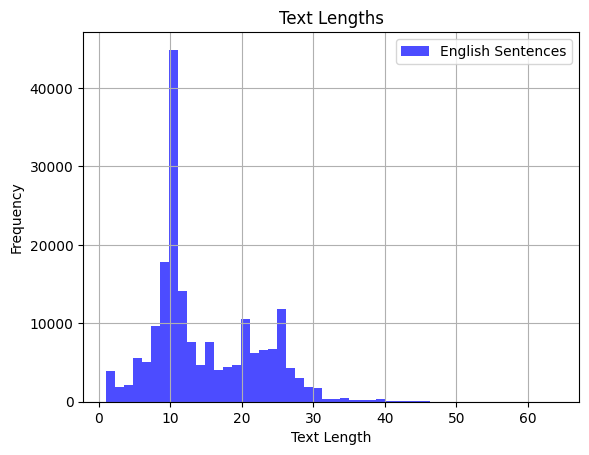

In [18]:
df_final['Text_seq_length'] = df_final['text'].apply(lambda x: len(x.split(' '))) # add a column for sequence length
df_final.hist(column="Text_seq_length", bins=50, alpha=0.7, color='blue', label='English Sentences') # plot histogram
plt.title('Text Lengths')
plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.legend(loc='upper right')
plt.show()

We next used a word cloud to optimize the stopwords lists.  We removed words that showed up heavily in both word clouds but didn't seem useful for bias detection.  We probably could have removed "today" but you have to stop somewhere!

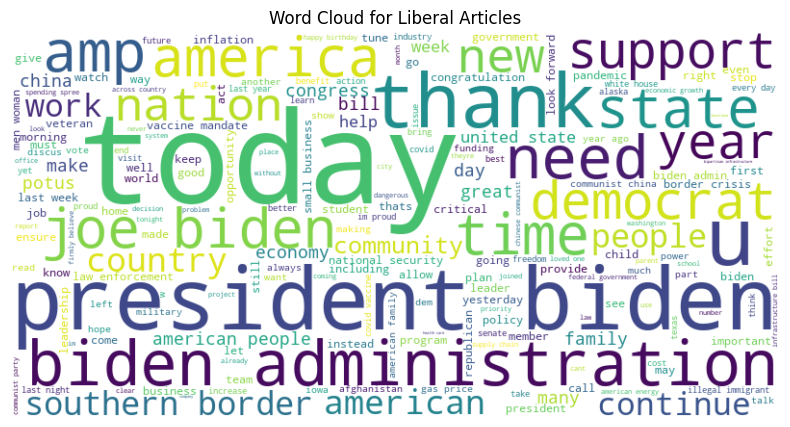

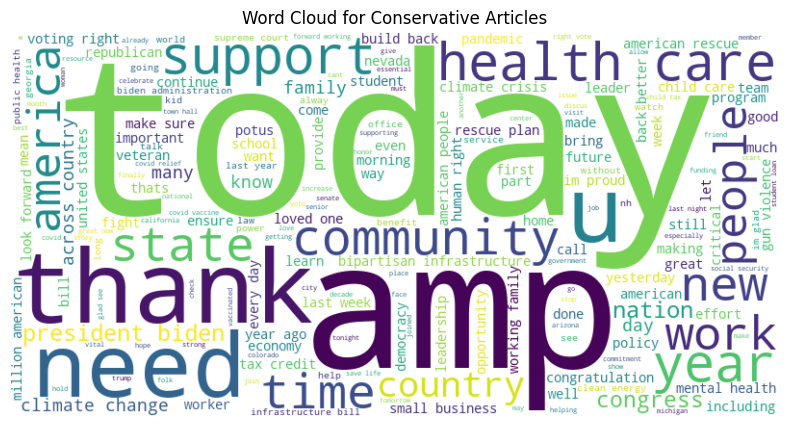

In [19]:
for bias, label in zip(['Liberal', 'Conservative'], [0, 1]):
    text = " ".join(df_final[df_final['label']==label]['text'])
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    
    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Word Cloud for {bias} Articles")
    plt.show()

Here we used CountVectorizer to get word counts and create another graph with the most common words from each dataset.

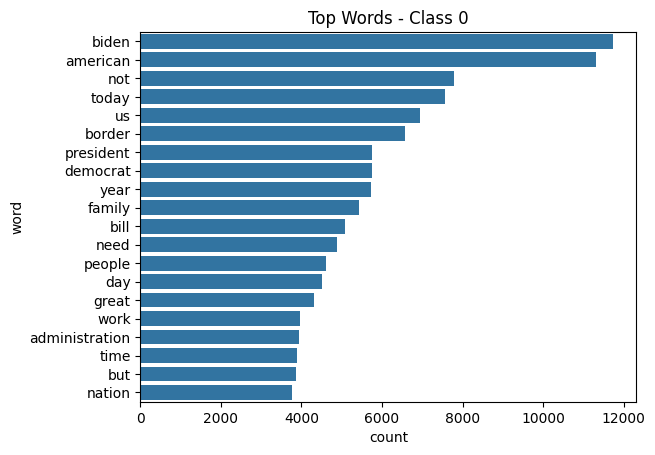

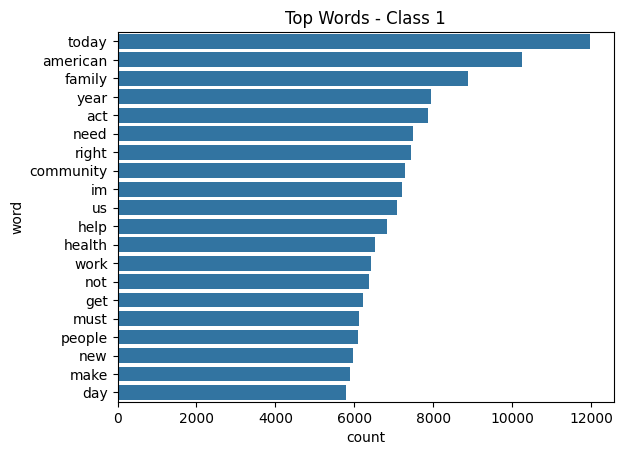

In [20]:
# simple vectorizer to find top words in each class
vectorizer = CountVectorizer(ngram_range=(1,3), max_features = 100) # used max_features to speed up runtime
X = vectorizer.fit_transform(df_final["text"])

words = vectorizer.get_feature_names_out()
df_counts = pd.DataFrame(X.toarray(), columns=words)

df_counts["label"] = df_final["label"].values

top0 = df_counts[df_counts["label"] == 0].drop(columns="label").sum()
top0 = top0.sort_values(ascending=False).head(20)

freq0 = top0.reset_index()
freq0.columns = ["word", "count"]

sns.barplot(x="count", y="word", data=freq0)
plt.title("Top Words - Class 0")
plt.show()

top1 = df_counts[df_counts["label"] == 1].drop(columns="label").sum()
top1 = top1.sort_values(ascending=False).head(20)

freq1 = top1.reset_index()
freq1.columns = ["word", "count"]

sns.barplot(x="count", y="word", data=freq1)
plt.title("Top Words - Class 1")
plt.show()

Lastly, we export the cleaned and preprocessed data to be used in the model.

In [21]:
df_final.drop(columns=['Text_seq_length'], inplace=True)
df_final.to_json("huggingFaceClean.json")

### Kaggle Datasets

The second working model was created using a Kaggle dataset which can be obtained at... https://www.kaggle.com/datasets/gandpablo/news-articles-for-political-bias-classification.  This a dataset with over 10,000 articles obtained by webscraping allsides.com, a platform that presents news articles from differing political perspectives.  The articles are labeled "leaning-left", "left", "center", "right", and "leaning-right".  

#### Data Acquisition and Preprocessing

In order to test this dataset on the same model, I again changed the five lables to only two: 0 for left and 1 for right.  I then dropped all nuetral articles to make this dataset comparable to the Hugging Face dataset.  

In [22]:
# Set file path
file_path = "bias_clean.csv"

# Load the latest version
df_kaggle = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "gandpablo/news-articles-for-political-bias-classification",
  file_path,
  # Provide any additional arguments like 
  # sql_query or pandas_kwargs. See the 
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/var/folders/wx/xm00n11n6xj5qds_xsdqlrvr0000gn/T/ipykernel_46290/2924201558.py:5: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df_kaggle = kagglehub.load_dataset(


First 5 records:                                                 text  label
0  The government should reduce taxes significant...      0
1  Cutting welfare programs is necessary to encou...      0
2  A strong military is essential for national se...      0
3  Deregulation is crucial to promote free market...      0
4  Traditional family values should be upheld to ...      0


In [23]:
# droppoing and renaming columns
df_kaggle.drop(columns=["url", "topic", "date", "site", "title"], inplace= True)
df_kaggle.rename(columns={"page_text": "text"}, inplace= True)
df_kaggle.head()

,bias,text
0,leaning-left,"What Got Us Through 2020? For Many, It Was Hob..."
1,leaning-left,New Year's Eve gatherings could accelerate COV...
2,leaning-right,Here’s how countries around the world are ring...
3,left,Police in Wisconsin said on Thursday evening t...
4,right,A Wisconsin-based hospital on Wednesday said a...


In [29]:
#checking the current labels to make sure there are no typos or different labels
print(df_kaggle["bias"].unique())

# remove the nuetral articles
df_kaggle = df_kaggle[df_kaggle["bias"] != 'center'].copy()

# apply new lables of 0 for left and 1 for right
df_kaggle["bias"].replace({
    "left": 0,
    "leaning-left": 0,
    "right": 1,
    "leaning-right": 1
}, inplace=True)
df_kaggle.reset_index(drop=True, inplace=True)
#check to see if it worked
df_kaggle.head(10)

KeyError: 'bias'

In [25]:
# change the name of the label column to match the other datasets for smoothe pipeline
df_kaggle.rename(columns= {"bias": "label"}, inplace = True)

Due to time constraints we did less data exploration and preprocessing for this dataset.  We simply applied the same preprocessing pipeline and tested the dataset with our model.  Ideally, we would adjust the stopwords to reflect this dataset and perform more analysis on text lengths and word counts.  

However, here we simply start by applying the same text cleaning function.  

In [26]:
# clean the text column of df
dfClean_kaggle = df_kaggle.copy()
dfClean_kaggle["text"] = dfClean_kaggle["text"].apply(clean_text) # clean Text column

dfClean_kaggle.head() # Check to see if it worked

,label,text
0,0,what got us through for many it was hobbies r...
1,0,new years eve gatherings could accelerate covi...
2,1,here’s how countries around the world are ring...
3,0,police in wisconsin said on thursday evening t...
4,1,a wisconsinbased hospital on wednesday said an...


Ideally, stopwords would be funetuned for this dataset but due to time constraints, we simply run the same preprocessing function.

In [27]:
df_final_kaggle = dfClean_kaggle.copy() # make a copy of the dataframe
df_final_kaggle['text'] = df_final_kaggle['text'].apply(preprocess_text) # apply preprocessing function to text
df_final_kaggle.head() # check to see if it works

,label,text
0,0,got us many hobby relationship legged pal got ...
1,0,new year eve gathering could accelerate covid ...
2,1,country around world ringing much world bade s...
3,0,police wisconsin thursday evening arrested hos...
4,1,wisconsinbased hospital wednesday employee rem...


The cleaned kaggleset is then exported as a json file.  

In [28]:
df_final_kaggle.to_json("KaggleClean.json")